# ML problem life-cycle
- problem understanding
- data collection
- data understanding
- data processing
- model building & training
- model evaluation
- model selection
- model deplpyment
- model monitoring

## problem :
- ice- cream sale prediction based on temperature
- dataset : icecream_sale_dataset.csv
- model: simple Linear Regression

In [1]:
# installation
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
"""
 Project :
│
├── Phase 0 : Business Understanding
├── Phase 1 : Setup
├── Phase 2 : Load Dataset
├── Phase 3 : Dataset Understanding
├── Phase 4 : Data Quality Assessment
├── Phase 5 : Exploratory Data Analysis (EDA)
├── Phase 6 : Data Cleaning
├── Phase 7 : Feature Engineering
├── Phase 8 : Feature Selection
├── Phase 9 : Data Preprocessing
├── Phase 10 : Train-Test Split
├── Phase 11 : Model Building
├── Phase 12 : Model Training
├── Phase 13 : Prediction
├── Phase 14 : Model Evaluation
├── Phase 15 : Model Improvement
├── Phase 16 : Business Conclusion
└── Phase 17 : Project Summary
"""

'\n Project :\n│\n├── Phase 0 : Business Understanding\n├── Phase 1 : Setup\n├── Phase 2 : Load Dataset\n├── Phase 3 : Dataset Understanding\n├── Phase 4 : Data Quality Assessment\n├── Phase 5 : Exploratory Data Analysis (EDA)\n├── Phase 6 : Data Cleaning\n├── Phase 7 : Feature Engineering\n├── Phase 8 : Feature Selection\n├── Phase 9 : Data Preprocessing\n├── Phase 10 : Train-Test Split\n├── Phase 11 : Model Building\n├── Phase 12 : Model Training\n├── Phase 13 : Prediction\n├── Phase 14 : Model Evaluation\n├── Phase 15 : Model Improvement\n├── Phase 16 : Business Conclusion\n└── Phase 17 : Project Summary\n'

In [3]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [4]:
# load
data=pd.read_csv("icecream_sales_dataset (2).csv")
data.head()

,Temperature_C,IceCream_Sales
0,30.523830,875.871197
1,26.956777,810.412847
2,36.489760,1109.021413
3,23.796323,710.135154
4,15.308535,472.521514


In [5]:
# data back=up
df=data.copy()
df.head()

,Temperature_C,IceCream_Sales
0,30.523830,875.871197
1,26.956777,810.412847
2,36.489760,1109.021413
3,23.796323,710.135154
4,15.308535,472.521514


In [6]:
df.tail()

,Temperature_C,IceCream_Sales
10015,35.313728,1014.844988
10016,36.024253,1083.798145
10017,19.183507,609.656190
10018,38.265829,1167.403102
10019,24.621365,735.809260


In [7]:
df.shape

(10020, 2)

In [8]:
df.sample(5)

,Temperature_C,IceCream_Sales
604,25.999131,788.575713
5262,32.813419,993.505496
8810,28.529595,866.865423
2330,38.164561,1141.045132
4148,30.234152,887.577857


In [9]:
# Dataset Understanding
print("no. of row :",df.shape[0])
print("no. of columns:",df.shape[1])
print("all columns names:",df.columns)
print("overall info \n")
df.info()
df.describe()

no. of row : 10020
no. of columns: 2
all columns names: Index(['Temperature_C', 'IceCream_Sales'], dtype='str')
overall info 

<class 'pandas.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature_C   10010 non-null  float64
 1   IceCream_Sales  10010 non-null  float64
dtypes: float64(2)
memory usage: 156.7 KB


,Temperature_C,IceCream_Sales
count,10010.000000,10010.000000
mean,29.820412,894.814442
std,8.627618,259.408346
min,15.000349,386.278839
25%,22.388703,670.545804
50%,29.773271,894.722954
75%,37.187301,1115.287009
max,44.991530,1395.058842


# Data Quality Assessment

In [10]:
# Missing Values
df.isnull().sum()

Temperature_C     10
IceCream_Sales    10
dtype: int64

In [11]:
# Duplicate Rows
df.duplicated().sum()
df[df.duplicated()]

,Temperature_C,IceCream_Sales
1457,17.440463,519.788776
3917,30.817654,924.451385
3922,29.778543,931.610047
4273,26.644971,794.960889
4324,22.423889,663.418223
5377,25.574431,782.456790
5404,25.124311,777.073261
6010,22.010713,654.411788
6296,23.935782,706.354443
6392,43.842527,1331.176249


In [12]:
# Data Type Validation
df.dtypes

Temperature_C     float64
IceCream_Sales    float64
dtype: object

In [13]:
# Invalid Values Check
print(df["Temperature_C"].min())
print(df["Temperature_C"].max())
print(df["IceCream_Sales"].min())
print(df["IceCream_Sales"].max())

15.000349042660984
44.99153019858392
386.2788392473449
1395.058841688286


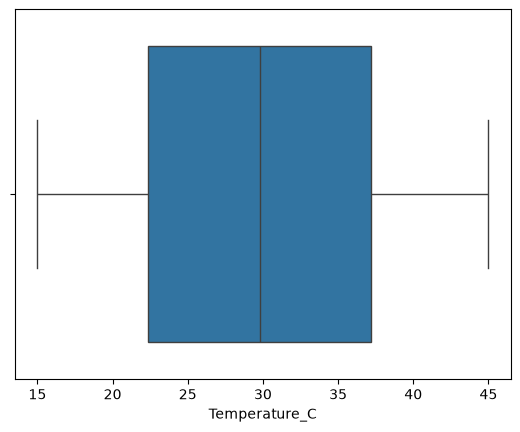

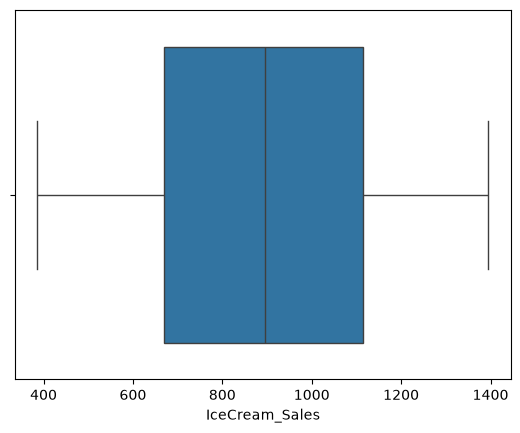

In [14]:
# outlier
sns.boxplot(x=df["Temperature_C"])
plt.show()

sns.boxplot(x=df["IceCream_Sales"])
plt.show()

# data cleaning

In [15]:
# delete missing value
df=df.dropna()
# to verify
df.isnull().sum()

Temperature_C     0
IceCream_Sales    0
dtype: int64

In [16]:
# remove duplicate rows
df=df.drop_duplicates()

# verify 
df.duplicated().sum()

np.int64(0)

In [17]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.shape)

Temperature_C     0
IceCream_Sales    0
dtype: int64
0
(9980, 2)


In [18]:
df.describe()

,Temperature_C,IceCream_Sales
count,9980.000000,9980.000000
mean,29.822430,894.914653
std,8.631672,259.482712
min,15.000349,386.278839
25%,22.379677,670.641581
50%,29.775593,894.783493
75%,37.214534,1115.580714
max,44.991530,1395.058842


# Exploratory Data Analysis (EDA)

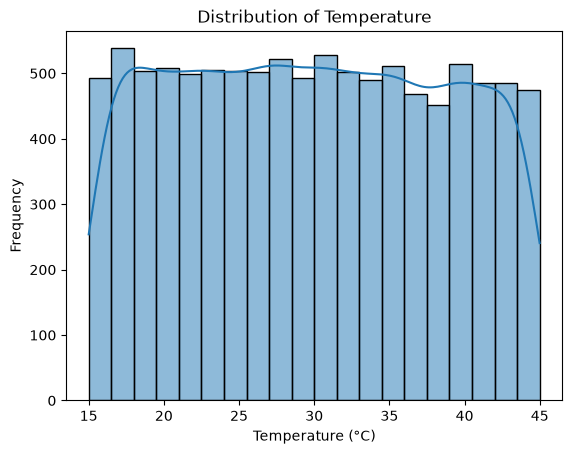

In [19]:
sns.histplot(df["Temperature_C"], bins=20, kde=True)
plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

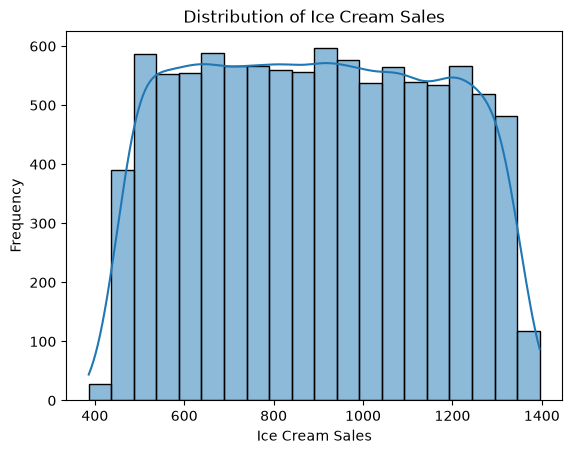

In [20]:
# distribution of ice cream sales
sns.histplot(df["IceCream_Sales"], bins=20, kde=True)
plt.title("Distribution of Ice Cream Sales")
plt.xlabel("Ice Cream Sales")
plt.ylabel("Frequency")
plt.show()

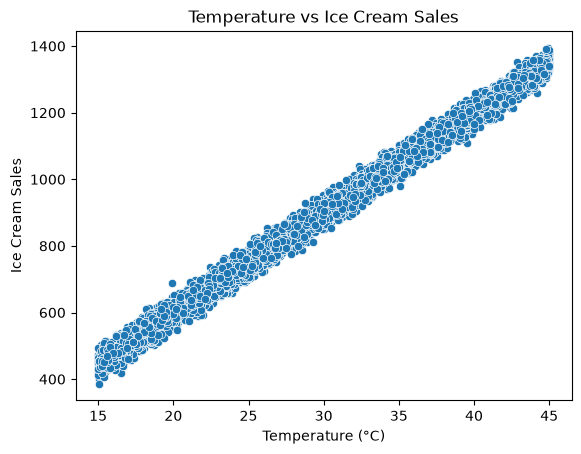

In [21]:
# relationship between temperature and ice cream sales
sns.scatterplot(x=df["Temperature_C"], y=df["IceCream_Sales"])
plt.title("Temperature vs Ice Cream Sales")
plt.xlabel("Temperature (°C)")
plt.ylabel("Ice Cream Sales")
plt.show()

In [22]:
# Correlation Analysis
df.corr()

,Temperature_C,IceCream_Sales
Temperature_C,1.000000,0.997027
IceCream_Sales,0.997027,1.000000


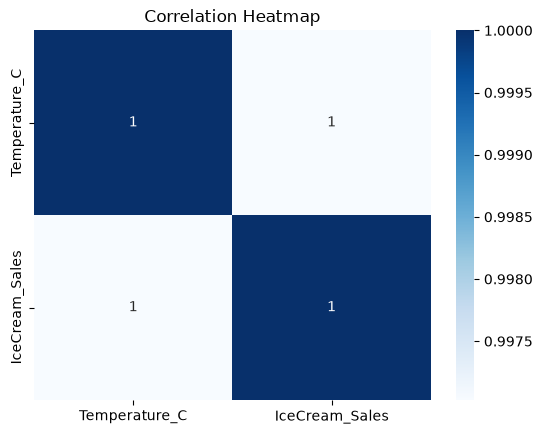

In [23]:
# Correlation Heatmap
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

# feature selection & Train-Test Split

In [24]:
#  select feature (X) and Target (y)
X = df[["Temperature_C"]]

y = df["IceCream_Sales"]

In [25]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [26]:
# verify the split (recommaended)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7984, 1)
(1996, 1)
(7984,)
(1996,)


# Build the Linear Regression model 

In [27]:
# creat the model
model=LinearRegression()

In [28]:
# train model
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[29.97]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Temperature_C']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.234
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [29]:
# make prediction
y_pred=model.predict(X_test)

In [30]:
y_pred.shape

(1996,)

# Comparison (Actual vs Prediction)

In [31]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,1172.998845,1181.120156
1,545.878857,592.101968
2,1062.873181,1058.641167
3,1042.490855,1042.442859
4,495.767249,466.955083
5,1106.610267,1090.910982
6,1204.757399,1188.703707
7,824.931234,837.706840
8,1284.483239,1272.203332
9,625.665337,659.771506


In [32]:
comparison = pd.DataFrame({
    "Temperature_C": X_test["Temperature_C"].values,
    "Actual_Sales": y_test.values,
    "Predicted_Sales": y_pred
})

comparison.head(10)

,Temperature_C,Actual_Sales,Predicted_Sales
0,39.372410,1172.998845,1181.120156
1,19.717070,545.878857,592.101968
2,35.285327,1062.873181,1058.641167
3,34.744795,1042.490855,1042.442859
4,15.540960,495.767249,466.955083
5,36.362160,1106.610267,1090.910982
6,39.625470,1204.757399,1188.703707
7,27.912822,824.931234,837.706840
8,42.411825,1284.483239,1272.203332
9,21.975180,625.665337,659.771506


In [33]:
y_pred=model.predict(X_test)
df_predict=pd.DataFrame({"actual": y_test, "prediction":y_pred})
df_predict.head(10)

,actual,prediction
1256,1172.998845,1181.120156
8255,545.878857,592.101968
1662,1062.873181,1058.641167
7759,1042.490855,1042.442859
1444,495.767249,466.955083
1059,1106.610267,1090.910982
35,1204.757399,1188.703707
7174,824.931234,837.706840
1666,1284.483239,1272.203332
4055,625.665337,659.771506


In [34]:
# (MAE) Mean Absolute Error
mae=metrics.mean_absolute_error(y_test,y_pred)
print(mae)

15.656578427747068


In [35]:
mse = metrics.mean_squared_error(y_test, y_pred)
print(mse)

384.4210003721629


In [36]:
r2 = metrics.r2_score(y_test, y_pred)
print(r2)

0.9941246391745079


In [37]:
prediction = model.predict([[55]])
print(prediction
     )

[1649.43741845]


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
